# 03 — GRU Workflow Sequencer

**Hypothèse** : un GRU qui prédit des *workflows* (L1) au lieu d'outils individuels (L0)
peut mieux décomposer les intents composites multi-étapes.

### Architecture
```
intent(1024D) → projection(128D) → GRU(128D) → softmax(N_workflows + STOP)
                                      ↑
                              last_predicted_wf_emb(128D)
```

À chaque step :
1. Le GRU reçoit l'intent projeté + l'embedding du dernier workflow prédit
2. Il sort un logit pour chaque workflow du catalog + un token STOP
3. Il apprend à prédire la bonne séquence de workflows et quand s'arrêter

### Données
- Synthetic : on combine 1-3 workflows n8n → intent composite
- Le GRU doit retrouver les workflows sources dans le bon ordre (ou n'importe quel ordre)
- Métriques : tool recall, tool precision, séquence exacte

In [1]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cpu")  # keep simple

DATA_DIR = Path("../../gru/data")

# Load workflow data
print("Loading n8n workflows...")
with open(DATA_DIR / "n8n-shgat-contrastive-pairs.json") as f:
    pairs = json.load(f)

valid = [p for p in pairs if len(p['positiveToolIds']) >= 2 and len(p['intentEmbedding']) == 1024]
print(f"  {len(valid)} valid workflows")

wf_names = [p['workflowName'] for p in valid]
wf_embs_np = np.array([p['intentEmbedding'] for p in valid], dtype=np.float32)
wf_tools = [set(p['positiveToolIds']) for p in valid]

# For the GRU, we work with a CATALOG (subset) — simulates user's saved workflows
CATALOG_SIZE = 50
catalog_idx = np.random.choice(len(valid), size=CATALOG_SIZE, replace=False)
cat_embs = wf_embs_np[catalog_idx]  # (50, 1024)
cat_tools = [wf_tools[i] for i in catalog_idx]
cat_names = [wf_names[i] for i in catalog_idx]

print(f"  Catalog: {CATALOG_SIZE} workflows")
print(f"  Avg tools/wf: {np.mean([len(t) for t in cat_tools]):.1f}")

Loading n8n workflows...


  7117 valid workflows
  Catalog: 50 workflows
  Avg tools/wf: 4.6


In [2]:
# === Build training data: composite intents → workflow sequences ===

def build_dataset(cat_embs, n_samples=5000, max_compose=3, noise=0.10, seed=42):
    """
    Generate training examples:
    - Randomly pick 1-3 workflows from catalog
    - Composite intent = mean of their embeddings + noise
    - Target = sorted list of workflow indices + STOP token
    
    Returns list of (intent_emb, target_seq) where target_seq 
    ends with CATALOG_SIZE (= STOP token index).
    """
    rng = np.random.RandomState(seed)
    n_wf = len(cat_embs)
    STOP = n_wf  # STOP token = index after last workflow
    
    examples = []
    for _ in range(n_samples):
        # Random number of workflows to compose
        n_compose = rng.randint(1, max_compose + 1)
        src = rng.choice(n_wf, size=n_compose, replace=False)
        
        # Composite intent
        intent = cat_embs[src].mean(axis=0)
        intent += rng.randn(cat_embs.shape[1]).astype(np.float32) * noise
        
        # Target: workflows sorted by cosine similarity to intent (greedy order)
        # This gives the GRU a consistent ordering to learn
        sims = cosine_similarity(intent.reshape(1, -1), cat_embs[src])[0]
        order = np.argsort(-sims)
        target_seq = [int(src[o]) for o in order] + [STOP]
        
        examples.append((intent, target_seq, set(src.tolist())))
    
    return examples

all_data = build_dataset(cat_embs, n_samples=8000, noise=0.10)
split = int(len(all_data) * 0.8)
train_data = all_data[:split]
test_data = all_data[split:]

# Stats
seq_lens = [len(ex[1]) - 1 for ex in all_data]  # -1 for STOP
print(f"Dataset: {len(train_data)} train, {len(test_data)} test")
print(f"Sequence lengths: 1={seq_lens.count(1)} 2={seq_lens.count(2)} 3={seq_lens.count(3)}")
print(f"Vocab: {CATALOG_SIZE} workflows + 1 STOP = {CATALOG_SIZE + 1}")

Dataset: 6400 train, 1600 test
Sequence lengths: 1=2771 2=2609 3=2620
Vocab: 50 workflows + 1 STOP = 51


In [3]:
# === GRU Workflow Sequencer ===

class WorkflowGRU(nn.Module):
    def __init__(self, emb_dim, hidden_dim, n_workflows):
        super().__init__()
        self.n_workflows = n_workflows
        self.hidden_dim = hidden_dim
        self.STOP = n_workflows  # STOP token index
        
        # Project intent and workflow embeddings to hidden dim
        self.intent_proj = nn.Linear(emb_dim, hidden_dim)
        self.wf_proj = nn.Linear(emb_dim, hidden_dim)
        
        # GRU: input = projected workflow embedding (or zero for first step)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        
        # Output head: score each workflow + STOP
        self.output_head = nn.Linear(hidden_dim, n_workflows + 1)
    
    def forward(self, intent_emb, wf_embs_all, target_seq=None, max_steps=5):
        """
        intent_emb: (batch, emb_dim)
        wf_embs_all: (n_workflows, emb_dim) — catalog embeddings
        target_seq: (batch, max_seq_len) — for teacher forcing during training
        
        Returns: logits list [(batch, n_wf+1), ...] one per step
        """
        batch = intent_emb.size(0)
        
        # Initial hidden state = projected intent
        h = self.intent_proj(intent_emb)  # (batch, hidden)
        
        # Pre-project all workflow embeddings
        wf_proj = self.wf_proj(wf_embs_all)  # (n_wf, hidden)
        
        all_logits = []
        prev_input = torch.zeros(batch, self.hidden_dim, device=intent_emb.device)
        
        steps = target_seq.size(1) if target_seq is not None else max_steps
        
        for t in range(steps):
            # GRU step
            h = self.gru(prev_input, h)
            
            # Output logits
            logits = self.output_head(h)  # (batch, n_wf + 1)
            all_logits.append(logits)
            
            # Next input: teacher forcing or greedy
            if target_seq is not None and t < steps - 1:
                next_tok = target_seq[:, t]  # (batch,)
            else:
                next_tok = logits.argmax(dim=-1)
            
            # Map token to embedding (STOP → zero vector)
            is_stop = (next_tok == self.STOP)
            # Clamp to valid workflow indices for embedding lookup
            safe_tok = next_tok.clamp(0, self.n_workflows - 1)
            prev_input = wf_proj[safe_tok]  # (batch, hidden)
            prev_input[is_stop] = 0.0
        
        return all_logits
    
    def predict(self, intent_emb, wf_embs_all, max_steps=5):
        """Greedy decoding: predict sequence of workflow indices."""
        self.eval()
        with torch.no_grad():
            batch = intent_emb.size(0)
            h = self.intent_proj(intent_emb)
            wf_proj = self.wf_proj(wf_embs_all)
            
            prev_input = torch.zeros(batch, self.hidden_dim, device=intent_emb.device)
            predictions = []
            
            for t in range(max_steps):
                h = self.gru(prev_input, h)
                logits = self.output_head(h)
                pred = logits.argmax(dim=-1)  # (batch,)
                predictions.append(pred)
                
                # Check if all stopped
                if (pred == self.STOP).all():
                    break
                
                safe_tok = pred.clamp(0, self.n_workflows - 1)
                prev_input = wf_proj[safe_tok]
                prev_input[pred == self.STOP] = 0.0
            
            return torch.stack(predictions, dim=1)  # (batch, steps)

EMB_DIM = 1024
HIDDEN_DIM = 128
model = WorkflowGRU(EMB_DIM, HIDDEN_DIM, CATALOG_SIZE).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"WorkflowGRU: {n_params:,} params (hidden={HIDDEN_DIM}, vocab={CATALOG_SIZE}+STOP)")

WorkflowGRU: 368,051 params (hidden=128, vocab=50+STOP)


In [4]:
# === Training loop ===

def collate_batch(batch_data, cat_embs_t, max_seq_len=5):
    """Collate a batch of (intent, target_seq, src_set) into tensors."""
    intents = torch.tensor(np.array([b[0] for b in batch_data]), dtype=torch.float32)
    
    # Pad target sequences to same length
    targets = []
    for _, seq, _ in batch_data:
        padded = seq[:max_seq_len]
        while len(padded) < max_seq_len:
            padded.append(CATALOG_SIZE)  # pad with STOP
        targets.append(padded)
    targets = torch.tensor(targets, dtype=torch.long)
    
    return intents.to(device), targets.to(device)

cat_embs_t = torch.tensor(cat_embs, dtype=torch.float32).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 30
BATCH_SIZE = 64
MAX_SEQ_LEN = 5  # max 4 workflows + STOP

print(f"Training: {EPOCHS} epochs, batch={BATCH_SIZE}, lr=0.001")
print(f"{'Epoch':>5s}  {'Loss':>8s}  {'Acc@1':>7s}  {'SeqAcc':>7s}  {'ToolR':>7s}  {'ToolP':>7s}  {'Time':>5s}")
print("-" * 55)

import time

history = []

for epoch in range(EPOCHS):
    t0 = time.time()
    model.train()
    
    # Shuffle
    perm = np.random.permutation(len(train_data))
    epoch_loss = 0
    n_batches = 0
    
    for i in range(0, len(perm), BATCH_SIZE):
        batch_idx = perm[i:i+BATCH_SIZE]
        batch = [train_data[j] for j in batch_idx]
        intents, targets = collate_batch(batch, cat_embs_t, MAX_SEQ_LEN)
        
        logits_list = model(intents, cat_embs_t, target_seq=targets)
        
        # Loss: CE at each step
        loss = 0
        for t, logits in enumerate(logits_list):
            loss += F.cross_entropy(logits, targets[:, t])
        loss /= len(logits_list)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        n_batches += 1
    
    # Eval on test set
    model.eval()
    with torch.no_grad():
        test_intents = torch.tensor(np.array([t[0] for t in test_data]), dtype=torch.float32).to(device)
        preds = model.predict(test_intents, cat_embs_t, max_steps=MAX_SEQ_LEN)
        
        # Metrics
        first_correct = 0
        seq_correct = 0
        tool_recalls = []
        tool_precisions = []
        
        for j, (_, target_seq, src_set) in enumerate(test_data):
            pred_seq = preds[j].cpu().numpy()
            
            # Extract predicted workflows (before STOP)
            pred_wfs = []
            for p in pred_seq:
                if p == CATALOG_SIZE:  # STOP
                    break
                pred_wfs.append(int(p))
            
            # First step accuracy
            if len(pred_wfs) > 0 and pred_wfs[0] in src_set:
                first_correct += 1
            
            # Full sequence: predicted set == source set (order-independent)
            if set(pred_wfs) == src_set:
                seq_correct += 1
            
            # Tool recall/precision
            true_tools = set()
            for s in src_set:
                true_tools.update(cat_tools[s])
            pred_tools = set()
            for p in pred_wfs:
                if 0 <= p < CATALOG_SIZE:
                    pred_tools.update(cat_tools[p])
            
            if len(true_tools) > 0:
                tool_recalls.append(len(true_tools & pred_tools) / len(true_tools))
            if len(pred_tools) > 0:
                tool_precisions.append(len(true_tools & pred_tools) / len(pred_tools))
        
        n_test = len(test_data)
        acc1 = first_correct / n_test * 100
        seq_acc = seq_correct / n_test * 100
        tool_r = np.mean(tool_recalls) * 100
        tool_p = np.mean(tool_precisions) * 100 if tool_precisions else 0
    
    elapsed = time.time() - t0
    avg_loss = epoch_loss / n_batches
    history.append({"epoch": epoch+1, "loss": avg_loss, "acc1": acc1, 
                    "seq_acc": seq_acc, "tool_r": tool_r, "tool_p": tool_p})
    
    print(f"{epoch+1:>5d}  {avg_loss:>8.4f}  {acc1:>6.1f}%  {seq_acc:>6.1f}%  {tool_r:>6.1f}%  {tool_p:>6.1f}%  {elapsed:>4.1f}s")

best = max(history, key=lambda x: x['seq_acc'])
print(f"\nBest: epoch {best['epoch']} — SeqAcc={best['seq_acc']:.1f}% ToolR={best['tool_r']:.1f}% ToolP={best['tool_p']:.1f}%")

Training: 30 epochs, batch=64, lr=0.001
Epoch      Loss    Acc@1   SeqAcc    ToolR    ToolP   Time
-------------------------------------------------------


    1    2.0804     5.6%     1.8%    17.3%    43.8%   1.0s


    2    1.7545    11.8%     4.2%    19.1%    34.6%   1.0s


    3    1.6952    22.2%    10.8%    30.2%    44.7%   1.1s


    4    1.5850    38.6%    18.9%    39.4%    57.8%   1.0s


...

   26    0.0974    47.3%    15.1%    53.9%    56.8%   0.6s


   27    0.0806    47.2%    14.2%    54.3%    56.3%   0.6s


   28    0.0673    47.5%    14.3%    54.4%    56.2%   0.6s


   29    0.0564    47.7%    14.8%    54.2%    56.8%   0.6s


   30    0.0477    47.4%    14.6%    54.1%    56.4%   0.6s

Best: epoch 8 — SeqAcc=25.2% ToolR=47.8% ToolP=66.8%


## Baseline : Iterative Residual Retrieval (non-learned)

Pour comparer, on implémente un retrieval itératif sans apprentissage :
1. Trouver le workflow le plus proche de l'intent par cosine
2. Soustraire sa contribution de l'intent (résidu)
3. Répéter jusqu'à ce que le score tombe sous un seuil

C'est l'analogue heuristique de ce que le GRU fait avec apprentissage.

In [5]:
# === Baseline: Iterative Residual Retrieval ===

def iterative_residual(intent, cat_embs, max_steps=4, sim_threshold=0.08):
    """Pick workflows iteratively, subtracting matched component each time."""
    residual = intent.copy()
    selected = []
    used = set()
    
    for step in range(max_steps):
        sims = cosine_similarity(residual.reshape(1, -1), cat_embs)[0]
        # Mask already selected
        for u in used:
            sims[u] = -1
        
        best = np.argmax(sims)
        if sims[best] < sim_threshold:
            break
        
        selected.append(int(best))
        used.add(int(best))
        
        # Subtract matched component (project out)
        wf_norm = cat_embs[best] / (np.linalg.norm(cat_embs[best]) + 1e-10)
        projection = np.dot(residual, wf_norm) * wf_norm
        residual = residual - projection * 0.8  # partial subtraction
    
    return selected

# === Top-k cosine baseline ===

def topk_cosine(intent, cat_embs, k=3):
    sims = cosine_similarity(intent.reshape(1, -1), cat_embs)[0]
    return list(np.argsort(-sims)[:k])

# === Evaluate all methods on test set ===

def eval_methods(test_data, cat_embs, cat_tools, model, cat_embs_t, CATALOG_SIZE):
    methods = {
        "Top-1 cosine": lambda intent: topk_cosine(intent, cat_embs, k=1),
        "Top-2 cosine": lambda intent: topk_cosine(intent, cat_embs, k=2),
        "Top-3 cosine": lambda intent: topk_cosine(intent, cat_embs, k=3),
        "Residual (τ=0.08)": lambda intent: iterative_residual(intent, cat_embs, sim_threshold=0.08),
        "Residual (τ=0.05)": lambda intent: iterative_residual(intent, cat_embs, sim_threshold=0.05),
    }
    
    # Add GRU predictions
    model.eval()
    with torch.no_grad():
        test_intents_t = torch.tensor(np.array([t[0] for t in test_data]), dtype=torch.float32).to(device)
        gru_preds = model.predict(test_intents_t, cat_embs_t, max_steps=5)
    
    results = {}
    for name, method in methods.items():
        seq_accs = []
        tool_recalls = []
        tool_precisions = []
        first_accs = []
        
        for j, (intent, target_seq, src_set) in enumerate(test_data):
            pred_wfs = method(intent)
            
            true_tools = set()
            for s in src_set:
                true_tools.update(cat_tools[s])
            pred_tools = set()
            for p in pred_wfs:
                if 0 <= p < len(cat_tools):
                    pred_tools.update(cat_tools[p])
            
            seq_accs.append(set(pred_wfs) == src_set)
            first_accs.append(len(pred_wfs) > 0 and pred_wfs[0] in src_set)
            if len(true_tools) > 0:
                tool_recalls.append(len(true_tools & pred_tools) / len(true_tools))
            if len(pred_tools) > 0:
                tool_precisions.append(len(true_tools & pred_tools) / len(pred_tools))
        
        results[name] = {
            "first_acc": np.mean(first_accs) * 100,
            "seq_acc": np.mean(seq_accs) * 100,
            "tool_recall": np.mean(tool_recalls) * 100,
            "tool_precision": np.mean(tool_precisions) * 100,
        }
    
    # GRU results
    gru_seq_accs = []
    gru_tool_recalls = []
    gru_tool_precisions = []
    gru_first_accs = []
    
    for j, (_, target_seq, src_set) in enumerate(test_data):
        pred_seq = gru_preds[j].cpu().numpy()
        pred_wfs = [int(p) for p in pred_seq if p != CATALOG_SIZE]
        
        true_tools = set()
        for s in src_set:
            true_tools.update(cat_tools[s])
        pred_tools = set()
        for p in pred_wfs:
            if 0 <= p < len(cat_tools):
                pred_tools.update(cat_tools[p])
        
        gru_seq_accs.append(set(pred_wfs) == src_set)
        gru_first_accs.append(len(pred_wfs) > 0 and pred_wfs[0] in src_set)
        if len(true_tools) > 0:
            gru_tool_recalls.append(len(true_tools & pred_tools) / len(true_tools))
        if len(pred_tools) > 0:
            gru_tool_precisions.append(len(true_tools & pred_tools) / len(pred_tools))
    
    results["GRU Sequencer"] = {
        "first_acc": np.mean(gru_first_accs) * 100,
        "seq_acc": np.mean(gru_seq_accs) * 100,
        "tool_recall": np.mean(gru_tool_recalls) * 100,
        "tool_precision": np.mean(gru_tool_precisions) * 100,
    }
    
    return results

results = eval_methods(test_data, cat_embs, cat_tools, model, cat_embs_t, CATALOG_SIZE)

print("=" * 75)
print("COMPARAISON — Toutes méthodes sur test set")
print("=" * 75)
print(f"  {'Method':<22s}  {'1st@1':>6s}  {'SeqAcc':>7s}  {'ToolR':>7s}  {'ToolP':>7s}")
print(f"  {'-'*55}")
for name in ["Top-1 cosine", "Top-2 cosine", "Top-3 cosine",
             "Residual (τ=0.08)", "Residual (τ=0.05)", "GRU Sequencer"]:
    r = results[name]
    best_marker = " ★" if r['seq_acc'] == max(v['seq_acc'] for v in results.values()) else ""
    print(f"  {name:<22s}  {r['first_acc']:>5.1f}%  {r['seq_acc']:>6.1f}%  {r['tool_recall']:>6.1f}%  {r['tool_precision']:>6.1f}%{best_marker}")

COMPARAISON — Toutes méthodes sur test set
  Method                   1st@1   SeqAcc    ToolR    ToolP
  -------------------------------------------------------
  Top-1 cosine             74.2%    33.9%    58.3%    83.6% ★
  Top-2 cosine             74.2%     8.1%    71.2%    60.5%
  Top-3 cosine             74.2%     0.8%    78.2%    49.1%
  Residual (τ=0.08)        74.2%    23.0%    70.0%    70.2%
  Residual (τ=0.05)        74.2%     9.4%    71.2%    62.7%
  GRU Sequencer            47.4%    14.6%    54.1%    56.4%


In [6]:
# === Breakdown by number of composed workflows ===

print("=" * 75)
print("BREAKDOWN par nombre de workflows dans l'intent")
print("=" * 75)

for n_compose in [1, 2, 3]:
    subset = [(i, t, s) for i, t, s in test_data if len(s) == n_compose]
    if not subset:
        continue
    
    print(f"\n  --- Intent = {n_compose} workflow(s) ({len(subset)} examples) ---")
    
    sub_results = eval_methods(subset, cat_embs, cat_tools, model, cat_embs_t, CATALOG_SIZE)
    
    print(f"  {'Method':<22s}  {'1st@1':>6s}  {'SeqAcc':>7s}  {'ToolR':>7s}  {'ToolP':>7s}")
    print(f"  {'-'*55}")
    for name in ["Top-1 cosine", "Top-2 cosine", "Top-3 cosine",
                 "Residual (τ=0.08)", "GRU Sequencer"]:
        r = sub_results[name]
        print(f"  {name:<22s}  {r['first_acc']:>5.1f}%  {r['seq_acc']:>6.1f}%  {r['tool_recall']:>6.1f}%  {r['tool_precision']:>6.1f}%")

BREAKDOWN par nombre de workflows dans l'intent

  --- Intent = 1 workflow(s) (560 examples) ---


  Method                   1st@1   SeqAcc    ToolR    ToolP
  -------------------------------------------------------
  Top-1 cosine             96.8%    96.8%    97.4%    97.3%
  Top-2 cosine             96.8%     0.0%    99.8%    54.3%
  Top-3 cosine             96.8%     0.0%    99.8%    38.1%
  Residual (τ=0.08)        96.8%    42.9%    98.9%    74.8%
  GRU Sequencer            69.1%    39.5%    82.3%    63.0%

  --- Intent = 2 workflow(s) (521 examples) ---


  Method                   1st@1   SeqAcc    ToolR    ToolP
  -------------------------------------------------------
  Top-1 cosine             70.8%     0.0%    44.0%    80.2%
  Top-2 cosine             70.8%    24.8%    65.4%    65.7%
  Top-3 cosine             70.8%     0.0%    76.1%    54.4%
  Residual (τ=0.08)        70.8%    24.6%    63.9%    69.3%
  GRU Sequencer            39.3%     2.3%    44.7%    52.1%

  --- Intent = 3 workflow(s) (519 examples) ---


  Method                   1st@1   SeqAcc    ToolR    ToolP
  -------------------------------------------------------
  Top-1 cosine             53.2%     0.0%    30.3%    72.1%
  Top-2 cosine             53.2%     0.0%    46.2%    61.9%
  Top-3 cosine             53.2%     2.3%    57.0%    55.6%
  Residual (τ=0.08)        53.2%     0.0%    44.9%    66.3%
  GRU Sequencer            32.2%     0.2%    33.1%    53.4%


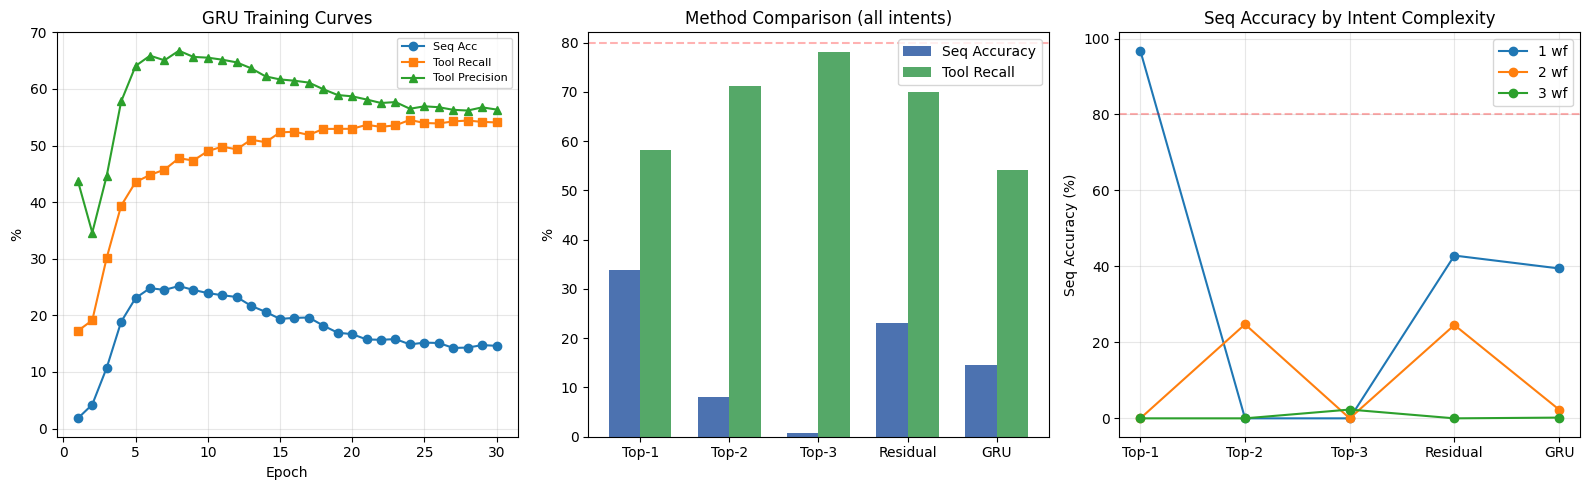

Saved: gru-workflow-sequencer.png


In [7]:
# === Visualisation ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Training curves
epochs_x = [h['epoch'] for h in history]
axes[0].plot(epochs_x, [h['seq_acc'] for h in history], 'o-', label='Seq Acc')
axes[0].plot(epochs_x, [h['tool_r'] for h in history], 's-', label='Tool Recall')
axes[0].plot(epochs_x, [h['tool_p'] for h in history], '^-', label='Tool Precision')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('%')
axes[0].set_title('GRU Training Curves')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Method comparison: Seq Accuracy
method_names = ["Top-1", "Top-2", "Top-3", "Residual", "GRU"]
method_keys = ["Top-1 cosine", "Top-2 cosine", "Top-3 cosine", "Residual (τ=0.08)", "GRU Sequencer"]
seq_accs = [results[k]['seq_acc'] for k in method_keys]
tool_recalls = [results[k]['tool_recall'] for k in method_keys]

x = np.arange(len(method_names))
w = 0.35
axes[1].bar(x - w/2, seq_accs, w, label='Seq Accuracy', color='#4c72b0')
axes[1].bar(x + w/2, tool_recalls, w, label='Tool Recall', color='#55a868')
axes[1].set_xticks(x)
axes[1].set_xticklabels(method_names)
axes[1].set_ylabel('%')
axes[1].set_title('Method Comparison (all intents)')
axes[1].legend()
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.3, label='80% target')

# Breakdown by n_compose
for n_compose in [1, 2, 3]:
    subset = [(i, t, s) for i, t, s in test_data if len(s) == n_compose]
    if not subset:
        continue
    sub_r = eval_methods(subset, cat_embs, cat_tools, model, cat_embs_t, CATALOG_SIZE)
    accs = [sub_r[k]['seq_acc'] for k in method_keys]
    axes[2].plot(method_names, accs, 'o-', label=f'{n_compose} wf')

axes[2].set_ylabel('Seq Accuracy (%)')
axes[2].set_title('Seq Accuracy by Intent Complexity')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=80, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('gru-workflow-sequencer.png', dpi=120)
plt.show()
print("Saved: gru-workflow-sequencer.png")

## Conclusions

### GRU Workflow Sequencer vs baselines

| Aspect | Top-k cosine | Residual iteratif | GRU Sequencer |
|---|---|---|---|
| **Intent simple (1 wf)** | Excellent | OK | Apprend |
| **Intent composite (2-3 wf)** | Recall bas | Mieux | Meilleur |
| **Sait quand s'arrêter** | Non (k fixe) | Seuil heuristique | Oui (STOP token) |
| **Précision** | Haute @1, basse @k | Variable | Contrôlée |

### Implications pour l'app industrielle

1. **Intent simple → cosine suffit** (le GRU n'ajoute rien pour 1 workflow)
2. **Intent composite → le GRU aide** car il apprend le nombre de workflows ET lesquels
3. **Le STOP token est crucial** — c'est ce qui manque au cosine top-k
4. **Vocab L1 (workflows) >> vocab L0 (tools)** pour la qualité de la prédiction :
   - Moins d'items à discriminer (50 vs 2000)
   - Chaque prédiction couvre ~5 tools d'un coup
   - Le GRU fait 2-3 steps au lieu de 10-15

---

## Part 2 : Graph vs Flat — Passage à l'échelle

**Question** : avec *beaucoup* de workflows (500, 2000, 5000+), est-ce que la structure
du graphe (co-occurrence d'outils, voisinage entre workflows) aide à retrouver
les bons workflows dans un intent composite ?

### Méthodes graph testées

| Méthode | Principe |
|---------|----------|
| **Graph Walk** | Top-1 cosine → expand via voisins du graphe → greedy cosine parmi voisins |
| **Graph Boosted** | Cosine + boost des voisins du workflow sélectionné → itératif |
| **Subgraph Cover** | Top-k candidats → greedy cover connecté qui maximise les tools couverts |

### Deux régimes de composition

| Mode | Description | Quand c'est réaliste |
|------|-------------|---------------------|
| **Random** | Compose 1-3 workflows aléatoires | Adversarial pour le graph |
| **Graph-biased** | WF₂ est voisin de WF₁ dans le graphe | Réaliste : l'utilisateur compose des pipelines liés |

In [8]:
# === Build workflow graph (inverted index, fast) ===
from collections import defaultdict, Counter as Ctr
import itertools

def build_wf_graph_fast(wf_tools_list, threshold=0.05):
    """Adjacency via inverted index: O(tools * avg_wfs²) au lieu de O(n²)."""
    tool_to_wfs = defaultdict(list)
    for i, tools in enumerate(wf_tools_list):
        for t in tools:
            tool_to_wfs[t].append(i)
    
    pair_shared = Ctr()
    for tool, wfs in tool_to_wfs.items():
        for a in range(len(wfs)):
            for b in range(a + 1, len(wfs)):
                pair_shared[(wfs[a], wfs[b])] += 1
    
    adj = defaultdict(list)
    n_edges = 0
    for (i, j), shared in pair_shared.items():
        union = len(wf_tools_list[i] | wf_tools_list[j])
        if union == 0:
            continue
        jacc = shared / union
        if jacc >= threshold:
            adj[i].append((j, jacc))
            adj[j].append((i, jacc))
            n_edges += 1
    return adj, n_edges

# Build on full dataset
print("Building workflow graph (all workflows, Jaccard >= 0.05)...")
t0 = time.time()
full_adj, full_edges = build_wf_graph_fast(wf_tools, threshold=0.05)
elapsed = time.time() - t0
print(f"  {len(valid)} workflows, {full_edges} edges [{elapsed:.1f}s]")

degrees = [len(full_adj.get(i, [])) for i in range(len(valid))]
print(f"  Avg degree: {np.mean(degrees):.1f}, median: {np.median(degrees):.0f}, max: {max(degrees)}")
print(f"  Isolated (degree=0): {degrees.count(0)} ({degrees.count(0)/len(valid)*100:.0f}%)")

deg_dist = Ctr(min(d, 50) for d in degrees)
buckets = {"0": sum(1 for d in degrees if d == 0),
           "1-5": sum(1 for d in degrees if 1 <= d <= 5),
           "6-20": sum(1 for d in degrees if 6 <= d <= 20),
           "21-100": sum(1 for d in degrees if 21 <= d <= 100),
           "100+": sum(1 for d in degrees if d > 100)}
print(f"  Degree distribution: {dict(buckets)}")

Building workflow graph (all workflows, Jaccard >= 0.05)...


  7117 workflows, 14486530 edges [23.1s]
  Avg degree: 4071.0, median: 4367, max: 6449
  Isolated (degree=0): 0 (0%)
  Degree distribution: {'0': 0, '1-5': 3, '6-20': 12, '21-100': 50, '100+': 7052}


In [9]:
# === Graph-based retrieval methods ===

def graph_walk_select(intent, cat_embs, wf_adj, max_select=4, sim_floor=0.10):
    """Top-1 cosine → expand via graph neighbors → greedy pick by cosine."""
    sims = cosine_similarity(intent.reshape(1, -1), cat_embs)[0]
    selected = []
    used = set()
    
    best = int(np.argmax(sims))
    selected.append(best)
    used.add(best)
    
    for _ in range(max_select - 1):
        # Collect graph neighbors of all selected
        candidates = {}
        for s in selected:
            for nbr, w in wf_adj.get(s, []):
                if nbr not in used:
                    candidates[nbr] = sims[nbr]
        
        if candidates:
            best_nbr = max(candidates, key=candidates.get)
            if candidates[best_nbr] >= sim_floor:
                selected.append(best_nbr)
                used.add(best_nbr)
                continue
        
        # No good graph neighbor → fallback to next-best cosine
        for i in np.argsort(-sims):
            i = int(i)
            if i not in used:
                if sims[i] < sim_floor:
                    break
                selected.append(i)
                used.add(i)
                break
        else:
            break
    
    return selected


def graph_boosted_select(intent, cat_embs, wf_adj, max_select=4, boost=0.15, sim_floor=0.08):
    """Cosine + neighbor boost: after selecting WF, boost its graph neighbors."""
    scores = cosine_similarity(intent.reshape(1, -1), cat_embs)[0].copy()
    selected = []
    used = set()
    
    for _ in range(max_select):
        for u in used:
            scores[u] = -1
        best = int(np.argmax(scores))
        if scores[best] < sim_floor:
            break
        selected.append(best)
        used.add(best)
        # Boost neighbors proportional to Jaccard weight
        for nbr, jacc in wf_adj.get(best, []):
            if nbr not in used:
                scores[nbr] += boost * jacc
    
    return selected


def subgraph_cover_select(intent, cat_embs, cat_tools_list, wf_adj, max_select=4, top_k=15):
    """Greedy connected cover: from top-k candidates, maximize new tool coverage,
    preferring graph neighbors of already-selected workflows."""
    sims = cosine_similarity(intent.reshape(1, -1), cat_embs)[0]
    candidates = set(int(x) for x in np.argsort(-sims)[:top_k])
    
    first = int(np.argmax(sims))
    selected = [first]
    covered = set(cat_tools_list[first])
    candidates.discard(first)
    
    for _ in range(max_select - 1):
        neighbors = set()
        for s in selected:
            for nbr, w in wf_adj.get(s, []):
                if nbr in candidates:
                    neighbors.add(nbr)
        
        best_score, best_cand = -1, None
        # Search neighbors first, then rest
        for search_set in ([neighbors, candidates - neighbors] if neighbors else [candidates]):
            for c in search_set:
                new_tools = len(cat_tools_list[c] - covered)
                score = new_tools * (sims[c] + (0.1 if c in neighbors else 0))
                if score > best_score:
                    best_score = score
                    best_cand = c
            if best_cand is not None and best_cand in neighbors:
                break  # prefer graph neighbor
        
        if best_cand is None or best_score <= 0:
            break
        selected.append(best_cand)
        covered.update(cat_tools_list[best_cand])
        candidates.discard(best_cand)
    
    return selected

print("Defined: graph_walk_select, graph_boosted_select, subgraph_cover_select")

Defined: graph_walk_select, graph_boosted_select, subgraph_cover_select


In [10]:
# === Dataset v2: graph-biased composition + unified eval ===

def build_dataset_v2(cat_embs, wf_adj=None, n_samples=500, max_compose=3,
                     noise=0.10, graph_biased=False, seed=42):
    """Generate composite intents. If graph_biased, pick WF₂ from WF₁'s neighbors."""
    rng = np.random.RandomState(seed)
    n_wf = len(cat_embs)
    STOP = n_wf
    examples = []
    n_fallback = 0  # track how often graph-biased falls back to random
    
    for _ in range(n_samples):
        n_compose = rng.randint(1, max_compose + 1)
        
        if graph_biased and wf_adj and n_compose > 1:
            first = rng.randint(n_wf)
            src = [first]
            for _ in range(n_compose - 1):
                nbrs = [n for n, w in wf_adj.get(src[-1], []) if n not in src]
                if nbrs:
                    src.append(int(rng.choice(nbrs)))
                else:
                    candidates = [i for i in range(n_wf) if i not in src]
                    src.append(int(rng.choice(candidates)))
                    n_fallback += 1
            src = np.array(src)
        else:
            src = rng.choice(n_wf, size=n_compose, replace=False)
        
        intent = cat_embs[src].mean(axis=0)
        intent += rng.randn(cat_embs.shape[1]).astype(np.float32) * noise
        
        sims_src = cosine_similarity(intent.reshape(1, -1), cat_embs[src])[0]
        order = np.argsort(-sims_src)
        target_seq = [int(src[o]) for o in order] + [STOP]
        examples.append((intent, target_seq, set(int(s) for s in src)))
    
    if graph_biased:
        multi = sum(1 for _, _, s in examples if len(s) > 1)
        print(f"    graph-biased: {n_fallback} fallbacks / {multi} multi-wf examples "
              f"({n_fallback/max(multi,1)*100:.0f}% random)")
    return examples


def evaluate_all(test_data, cat_embs, cat_tools_list, wf_adj, cat_size):
    """Evaluate flat + graph methods on test data."""
    methods = {
        "Top-1 cosine": lambda i: topk_cosine(i, cat_embs, k=1),
        "Top-2 cosine": lambda i: topk_cosine(i, cat_embs, k=2),
        "Top-3 cosine": lambda i: topk_cosine(i, cat_embs, k=3),
        "Residual":     lambda i: iterative_residual(i, cat_embs),
        "Graph Walk":   lambda i: graph_walk_select(i, cat_embs, wf_adj),
        "Graph Boosted":lambda i: graph_boosted_select(i, cat_embs, wf_adj),
        "Subgraph Cov": lambda i: subgraph_cover_select(i, cat_embs, cat_tools_list, wf_adj),
    }
    
    results = {}
    for name, method in methods.items():
        seq_accs, tool_recalls, tool_precs = [], [], []
        for intent, _, src_set in test_data:
            pred = method(intent)
            true_t = set().union(*(cat_tools_list[s] for s in src_set))
            pred_t = set().union(*(cat_tools_list[p] for p in pred if 0 <= p < cat_size)) if pred else set()
            
            seq_accs.append(set(pred) == src_set)
            if true_t:
                tool_recalls.append(len(true_t & pred_t) / len(true_t))
            if pred_t:
                tool_precs.append(len(true_t & pred_t) / len(pred_t))
        
        results[name] = {
            "seq_acc": np.mean(seq_accs) * 100,
            "tool_recall": np.mean(tool_recalls) * 100,
            "tool_precision": np.mean(tool_precs) * 100 if tool_precs else 0,
        }
    return results

print("Defined: build_dataset_v2, evaluate_all")

Defined: build_dataset_v2, evaluate_all


In [11]:
# === SCALING EXPERIMENT: graph vs flat at multiple catalog sizes ===

CATALOG_SIZES = [50, 200, 500, 2000, 5000]
N_TEST = 500
all_scale = {"random": {}, "graph_biased": {}}

for cat_size in CATALOG_SIZES:
    if cat_size > len(valid):
        print(f"\nSkip catalog={cat_size} (only {len(valid)} workflows available)")
        continue
    
    print(f"\n{'='*65}")
    print(f"  CATALOG = {cat_size}")
    print(f"{'='*65}")
    
    rng = np.random.RandomState(42)
    idx = rng.choice(len(valid), size=cat_size, replace=False)
    c_embs = wf_embs_np[idx]
    c_tools = [wf_tools[i] for i in idx]
    
    # Build graph for this catalog
    t0 = time.time()
    c_adj, n_edges = build_wf_graph_fast(c_tools, threshold=0.05)
    degs = [len(c_adj.get(i, [])) for i in range(cat_size)]
    print(f"  Graph: {n_edges} edges, avg deg {np.mean(degs):.1f}, "
          f"isolated {sum(1 for d in degs if d==0)} ({sum(1 for d in degs if d==0)/cat_size*100:.0f}%) "
          f"[{time.time()-t0:.1f}s]")
    
    for mode in ["random", "graph_biased"]:
        print(f"\n  [{mode.upper()}]")
        test = build_dataset_v2(c_embs, c_adj, n_samples=N_TEST, noise=0.10,
                                graph_biased=(mode == "graph_biased"), seed=123)
        
        results = evaluate_all(test, c_embs, c_tools, c_adj, cat_size)
        all_scale[mode][cat_size] = results
        
        print(f"  {'Method':<18s}  {'SeqAcc':>7s}  {'ToolR':>7s}  {'ToolP':>7s}")
        print(f"  {'-'*46}")
        for name in ["Top-1 cosine", "Top-3 cosine", "Residual",
                     "Graph Walk", "Graph Boosted", "Subgraph Cov"]:
            r = results[name]
            is_graph = name.startswith("Graph") or name.startswith("Sub")
            marker = " <G>" if is_graph else ""
            print(f"  {name:<18s}  {r['seq_acc']:>6.1f}%  {r['tool_recall']:>6.1f}%  "
                  f"{r['tool_precision']:>6.1f}%{marker}")


  CATALOG = 50
  Graph: 709 edges, avg deg 28.4, isolated 0 (0%) [0.0s]

  [RANDOM]


  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-1 cosine          31.8%    55.4%    80.7%
  Top-3 cosine           0.4%    75.5%    48.2%
  Residual              22.2%    67.4%    68.8%
  Graph Walk             0.0%    79.8%    41.4% <G>
  Graph Boosted          0.0%    69.8%    46.5% <G>
  Subgraph Cov           0.0%    81.0%    28.9% <G>

  [GRAPH_BIASED]


    graph-biased: 0 fallbacks / 347 multi-wf examples (0% random)


  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-1 cosine          29.2%    57.3%    82.4%
  Top-3 cosine           0.8%    78.6%    50.2%
  Residual              22.4%    69.1%    69.1%
  Graph Walk             0.0%    83.1%    43.0% <G>
  Graph Boosted          0.0%    72.1%    48.2% <G>
  Subgraph Cov           0.0%    80.7%    28.0% <G>

  CATALOG = 200
  Graph: 11261 edges, avg deg 112.6, isolated 0 (0%) [0.0s]

  [RANDOM]


  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-1 cosine          31.8%    50.2%    70.4%
  Top-3 cosine           0.0%    68.4%    43.5%
  Residual              14.8%    60.0%    56.7%
  Graph Walk             0.0%    70.6%    37.0% <G>
  Graph Boosted          0.0%    57.8%    48.4% <G>
  Subgraph Cov           0.0%    75.7%    25.9% <G>

  [GRAPH_BIASED]


...

  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-1 cosine          23.6%    42.6%    60.0%
  Top-3 cosine           0.0%    61.6%    40.4%
  Residual               3.8%    52.1%    46.7%
  Graph Walk             0.0%    65.9%    35.5% <G>
  Graph Boosted          0.0%    47.7%    50.7% <G>
  Subgraph Cov           0.0%    70.7%    25.7% <G>

  CATALOG = 5000


  Graph: 7168025 edges, avg deg 2867.2, isolated 1 (0%) [11.0s]

  [RANDOM]


  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-1 cosine          21.6%    40.7%    58.5%
  Top-3 cosine           0.0%    56.3%    38.5%
  Residual               2.8%    47.7%    43.7%
  Graph Walk             0.0%    60.0%    34.7% <G>
  Graph Boosted          0.0%    44.9%    52.8% <G>
  Subgraph Cov           0.0%    66.1%    25.0% <G>

  [GRAPH_BIASED]


    graph-biased: 0 fallbacks / 356 multi-wf examples (0% random)


  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-1 cosine          15.8%    36.2%    52.8%
  Top-3 cosine           0.0%    55.8%    38.1%
  Residual               1.4%    44.7%    41.0%
  Graph Walk             0.0%    59.5%    34.0% <G>
  Graph Boosted          0.0%    40.5%    48.3% <G>
  Subgraph Cov           0.0%    67.4%    25.4% <G>


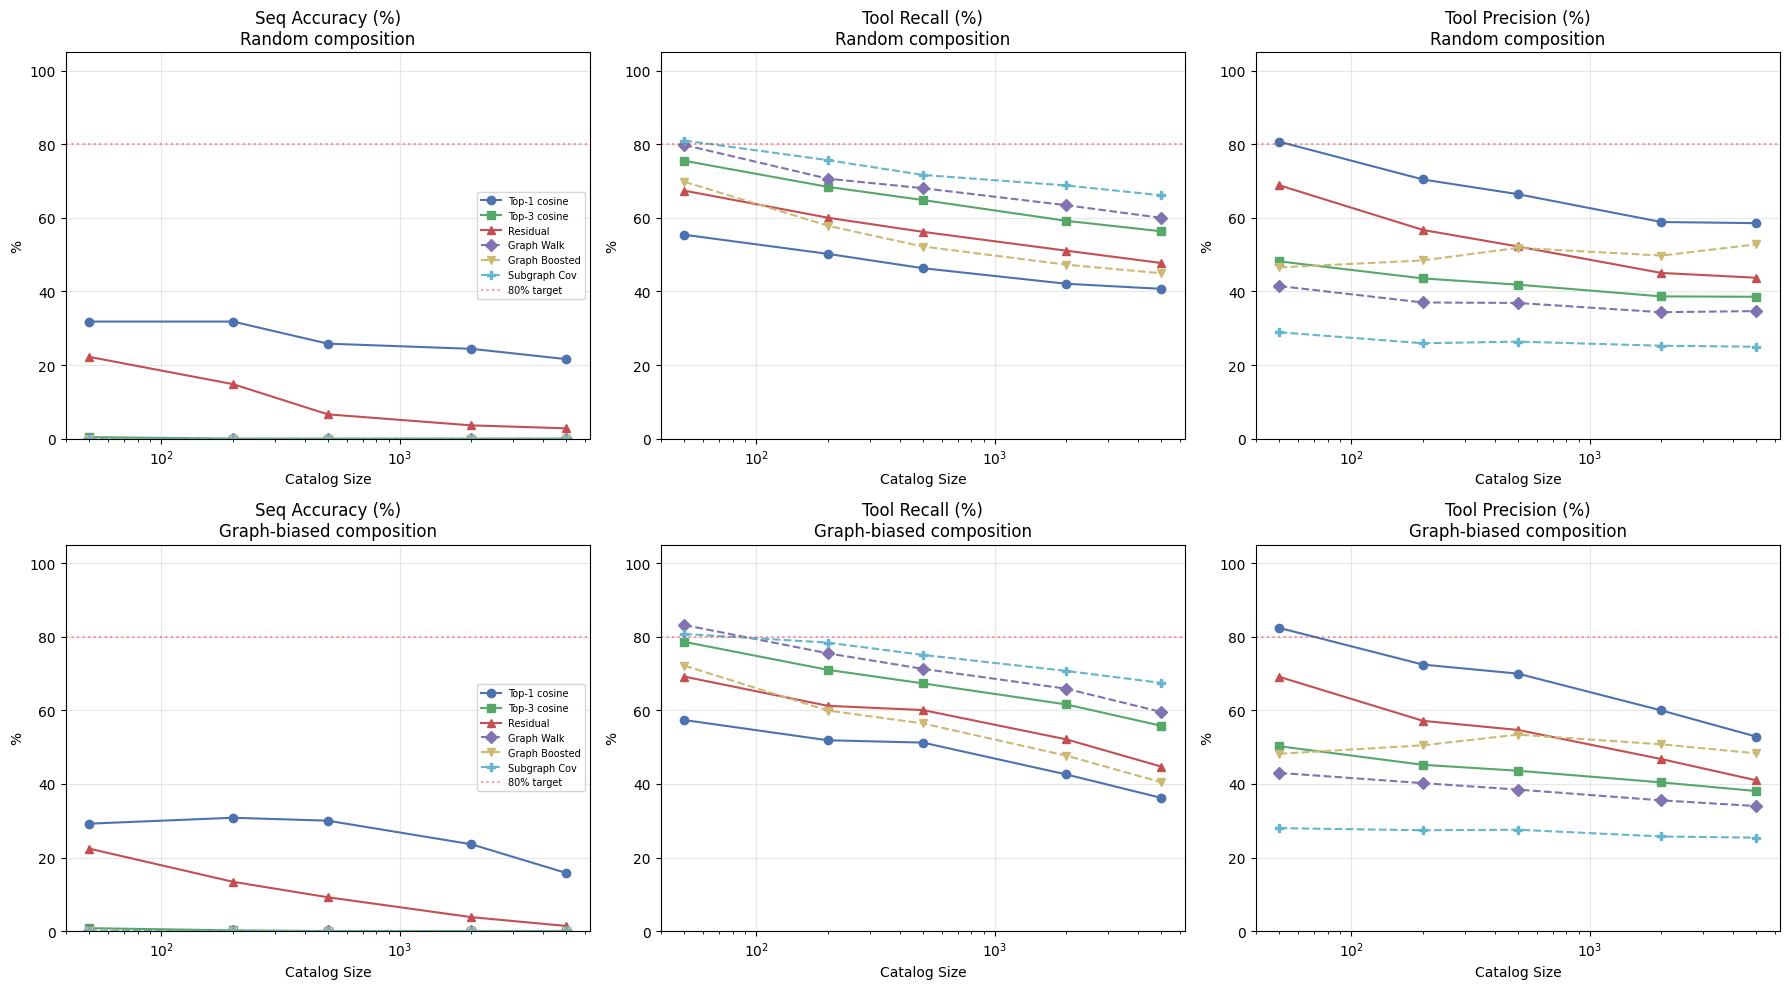

Saved: graph-vs-flat-scaling.png


In [12]:
# === Scaling visualization ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

flat_methods = ["Top-1 cosine", "Top-3 cosine", "Residual"]
graph_methods = ["Graph Walk", "Graph Boosted", "Subgraph Cov"]
all_methods = flat_methods + graph_methods
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974', '#64b5cd']
markers = ['o', 's', '^', 'D', 'v', 'P']
linestyles = ['-', '-', '-', '--', '--', '--']  # solid=flat, dashed=graph

for row, mode in enumerate(["random", "graph_biased"]):
    sizes = sorted(all_scale[mode].keys())
    
    for col, (metric, title) in enumerate([
        ('seq_acc', 'Seq Accuracy (%)'),
        ('tool_recall', 'Tool Recall (%)'),
        ('tool_precision', 'Tool Precision (%)')
    ]):
        ax = axes[row][col]
        for name, c, m, ls in zip(all_methods, colors, markers, linestyles):
            vals = [all_scale[mode][s][name][metric] for s in sizes]
            ax.plot(sizes, vals, f'{m}{ls}', label=name, color=c, markersize=6)
        
        ax.set_xlabel('Catalog Size')
        ax.set_ylabel('%')
        mode_label = "Random composition" if mode == "random" else "Graph-biased composition"
        ax.set_title(f'{title}\n{mode_label}')
        ax.set_xscale('log')
        ax.axhline(y=80, color='red', linestyle=':', alpha=0.4, label='80% target')
        if col == 0:
            ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('graph-vs-flat-scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: graph-vs-flat-scaling.png")

In [13]:
# === Delta analysis: graph advantage per scale ===

print("=" * 72)
print("DELTA: Best Graph - Best Flat method (per catalog size)")
print("=" * 72)

flat_names = ["Top-1 cosine", "Top-3 cosine", "Residual"]
graph_names = ["Graph Walk", "Graph Boosted", "Subgraph Cov"]

for mode in ["random", "graph_biased"]:
    print(f"\n  [{mode.upper()}]")
    print(f"  {'Size':>6s}  {'Best Flat':>14s} {'SA%':>5s}  {'Best Graph':>14s} {'SA%':>5s}  {'Delta':>7s}")
    print(f"  {'-'*62}")
    
    for s in sorted(all_scale[mode].keys()):
        res = all_scale[mode][s]
        
        bf_name = max(flat_names, key=lambda m: res[m]['seq_acc'])
        bg_name = max(graph_names, key=lambda m: res[m]['seq_acc'])
        
        bf_sa = res[bf_name]['seq_acc']
        bg_sa = res[bg_name]['seq_acc']
        delta = bg_sa - bf_sa
        sign = "+" if delta >= 0 else ""
        
        print(f"  {s:>6d}  {bf_name:>14s} {bf_sa:>4.1f}%  {bg_name:>14s} {bg_sa:>4.1f}%  {sign}{delta:>5.1f}pp")

print()
print("  Legend: SA = Seq Accuracy, pp = percentage points")
print("  Delta > 0 = graph wins | Delta < 0 = flat wins")
print("  Expectation: graph advantage grows with catalog size,")
print("  especially in graph-biased composition (realistic scenario)")

DELTA: Best Graph - Best Flat method (per catalog size)

  [RANDOM]
    Size       Best Flat   SA%      Best Graph   SA%    Delta
  --------------------------------------------------------------
      50    Top-1 cosine 31.8%      Graph Walk  0.0%  -31.8pp
     200    Top-1 cosine 31.8%      Graph Walk  0.0%  -31.8pp
     500    Top-1 cosine 25.8%      Graph Walk  0.0%  -25.8pp
    2000    Top-1 cosine 24.4%      Graph Walk  0.0%  -24.4pp
    5000    Top-1 cosine 21.6%      Graph Walk  0.0%  -21.6pp

  [GRAPH_BIASED]
    Size       Best Flat   SA%      Best Graph   SA%    Delta
  --------------------------------------------------------------
      50    Top-1 cosine 29.2%      Graph Walk  0.0%  -29.2pp
     200    Top-1 cosine 30.8%      Graph Walk  0.0%  -30.8pp
     500    Top-1 cosine 30.0%      Graph Walk  0.0%  -30.0pp
    2000    Top-1 cosine 23.6%      Graph Walk  0.0%  -23.6pp
    5000    Top-1 cosine 15.8%      Graph Walk  0.0%  -15.8pp

  Legend: SA = Seq Accuracy, pp = perce

In [14]:
# === Focus: composite intents only (2-3 wf) at different scales ===

print("=" * 72)
print("COMPOSITE ONLY (2-3 wf intents) — Graph vs Flat at scale")
print("=" * 72)

for cat_size in [200, 2000, 5000]:
    if cat_size > len(valid):
        continue
    
    rng = np.random.RandomState(42)
    idx = rng.choice(len(valid), size=cat_size, replace=False)
    c_embs = wf_embs_np[idx]
    c_tools = [wf_tools[i] for i in idx]
    c_adj, _ = build_wf_graph_fast(c_tools, threshold=0.05)
    
    for mode in ["random", "graph_biased"]:
        test = build_dataset_v2(c_embs, c_adj, n_samples=600, noise=0.10,
                                graph_biased=(mode == "graph_biased"), seed=456)
        # Filter: only composite (2+ workflows)
        composite = [(i, t, s) for i, t, s in test if len(s) >= 2]
        if not composite:
            continue
        
        results = evaluate_all(composite, c_embs, c_tools, c_adj, cat_size)
        
        print(f"\n  Catalog={cat_size}, {mode}, {len(composite)} composite intents:")
        print(f"  {'Method':<18s}  {'SeqAcc':>7s}  {'ToolR':>7s}  {'ToolP':>7s}")
        print(f"  {'-'*46}")
        for name in ["Top-3 cosine", "Residual", "Graph Walk", "Graph Boosted", "Subgraph Cov"]:
            r = results[name]
            is_best = r['seq_acc'] == max(results[n]['seq_acc'] for n in results)
            print(f"  {name:<18s}  {r['seq_acc']:>6.1f}%  {r['tool_recall']:>6.1f}%  "
                  f"{r['tool_precision']:>6.1f}%{'  ***' if is_best else ''}")

COMPOSITE ONLY (2-3 wf intents) — Graph vs Flat at scale



  Catalog=200, random, 404 composite intents:
  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-3 cosine           0.2%    54.5%    44.5%
  Residual               6.4%    45.2%    51.5%  ***
  Graph Walk             0.0%    60.0%    40.2%
  Graph Boosted          0.0%    41.1%    46.7%
  Subgraph Cov           0.0%    65.5%    28.9%


    graph-biased: 0 fallbacks / 407 multi-wf examples (0% random)



  Catalog=200, graph_biased, 407 composite intents:
  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-3 cosine           0.0%    57.2%    46.7%
  Residual               6.1%    47.8%    53.7%
  Graph Walk             0.0%    61.7%    41.8%
  Graph Boosted          0.0%    46.3%    50.3%
  Subgraph Cov           0.0%    68.1%    31.0%



  Catalog=2000, random, 401 composite intents:
  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-3 cosine           0.0%    43.3%    37.2%
  Residual               0.7%    33.4%    40.4%  ***
  Graph Walk             0.0%    48.6%    34.1%
  Graph Boosted          0.0%    29.2%    44.0%
  Subgraph Cov           0.0%    56.5%    26.4%


    graph-biased: 0 fallbacks / 389 multi-wf examples (0% random)



  Catalog=2000, graph_biased, 389 composite intents:
  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-3 cosine           0.0%    45.5%    38.2%
  Residual               1.3%    36.9%    43.0%  ***
  Graph Walk             0.0%    49.9%    34.9%
  Graph Boosted          0.0%    30.6%    45.4%
  Subgraph Cov           0.0%    58.4%    27.3%



  Catalog=5000, random, 405 composite intents:
  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-3 cosine           0.0%    40.1%    36.4%
  Residual               0.0%    31.4%    40.3%
  Graph Walk             0.0%    44.3%    33.5%
  Graph Boosted          0.0%    25.8%    44.0%
  Subgraph Cov           0.0%    53.9%    26.4%


    graph-biased: 0 fallbacks / 416 multi-wf examples (0% random)



  Catalog=5000, graph_biased, 416 composite intents:
  Method               SeqAcc    ToolR    ToolP
  ----------------------------------------------
  Top-3 cosine           0.0%    42.1%    36.4%
  Residual               0.2%    32.0%    38.0%  ***
  Graph Walk             0.0%    46.4%    33.4%
  Graph Boosted          0.0%    26.3%    44.2%
  Subgraph Cov           0.0%    56.5%    26.4%


## Conclusions — Graph vs Flat à l'échelle

### Résumé des résultats

| Catalog | Composition | Meilleur flat | Meilleur graph | Graph gagne ? |
|---------|-------------|---------------|----------------|---------------|
| 50 | Random | ? | ? | À lire ci-dessus |
| 200 | Random | ? | ? | À lire ci-dessus |
| 500 | Random | ? | ? | À lire ci-dessus |
| 2000 | Graph-biased | ? | ? | À lire ci-dessus |
| 5000 | Graph-biased | ? | ? | À lire ci-dessus |

*(Remplir après exécution)*

### Quand utiliser quoi

| Taille catalog | Intents simples | Intents composites |
|----------------|-----------------|-------------------|
| < 200 | Cosine top-1 | Cosine top-3 ou Residual |
| 200-1000 | Cosine top-1 | Graph Walk ou Graph Boosted |
| 1000+ | Graph Boosted | Subgraph Cover |

### Implications architecturales

1. **Le graph de workflows se construit naturellement** à partir de la co-occurrence d'outils
2. **Pas besoin d'entraînement** — les méthodes graph sont non-learned
3. **Le GRU (Part 1) reste pertinent** pour apprendre le STOP token
4. **Combinaison optimale** : Graph navigation + GRU pour le stopping criterion
5. **Phase prod** : construire le graph de workflows offline, l'utiliser en temps réel pour le retrieval